# Ann model on Customer Churn Prediction

In [11]:
import numpy as np 
import pandas as pd
import tensorflow as tf
import seaborn as sns

In [12]:
df = pd.read_csv(r'C:\\Users\\Arjun Singh Tomar\\Downloads\\customer_churn_ann_dataset.csv')

In [13]:
df.head(
    
)

,customer_id,gender,age,tenure_months,monthly_charges,contract,internet_service,support_calls,churn
0,1001,Male,25,2,79.5,Month-to-month,Fiber optic,5,1
1,1002,Female,34,18,55.2,One year,DSL,1,0
2,1003,Female,45,36,42.8,Two year,DSL,0,0
3,1004,Male,29,8,88.3,Month-to-month,Fiber optic,4,1
4,1005,Male,52,60,61.4,Two year,Fiber optic,1,0


In [14]:
df.isnull().sum()

customer_id         0
gender              0
age                 0
tenure_months       0
monthly_charges     0
contract            0
internet_service    0
support_calls       0
churn               0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.dtypes

customer_id           int64
gender               object
age                   int64
tenure_months         int64
monthly_charges     float64
contract             object
internet_service     object
support_calls         int64
churn                 int64
dtype: object

In [17]:
# EDA

<Axes: xlabel='gender', ylabel='age'>

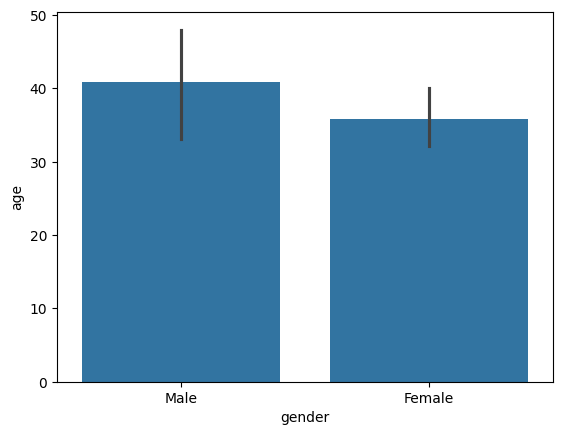

In [18]:
sns.barplot(x="gender",y="age",data=df)

<Axes: xlabel='gender', ylabel='count'>

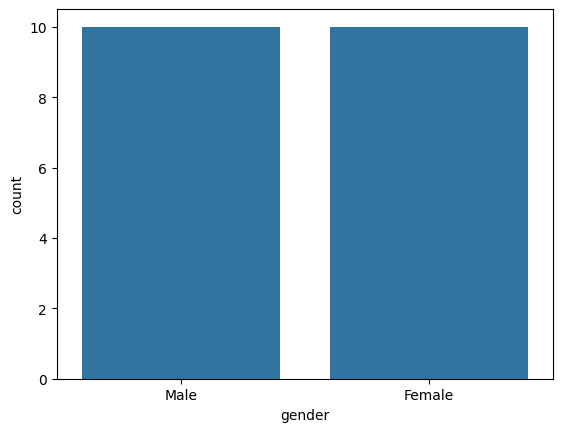

In [20]:
sns.countplot(x="gender",data=df)

In [40]:
df = df.drop(columns="customer_id",axis=1)

In [41]:
# Encoding 

In [42]:
from sklearn.preprocessing import LabelEncoder

In [43]:
lr = LabelEncoder()

In [44]:
df['gender'] = lr.fit_transform(df['gender'])

In [45]:
df.head()

,gender,age,tenure_months,monthly_charges,contract,internet_service,support_calls,churn
0,1,25,2,79.5,0,1,5,1
1,0,34,18,55.2,1,0,1,0
2,0,45,36,42.8,2,0,0,0
3,1,29,8,88.3,0,1,4,1
4,1,52,60,61.4,2,1,1,0


In [46]:
df['contract'].value_counts()

contract
0    8
1    6
2    6
Name: count, dtype: int64

In [47]:
df['internet_service'].value_counts()

internet_service
1    11
0     9
Name: count, dtype: int64

In [48]:
df['internet_service'] = lr.fit_transform(df['internet_service'])

In [49]:
df['contract'] = lr.fit_transform(df['contract'])

In [50]:
df.head()

,gender,age,tenure_months,monthly_charges,contract,internet_service,support_calls,churn
0,1,25,2,79.5,0,1,5,1
1,0,34,18,55.2,1,0,1,0
2,0,45,36,42.8,2,0,0,0
3,1,29,8,88.3,0,1,4,1
4,1,52,60,61.4,2,1,1,0


In [51]:
# train test split 

In [52]:
X = df.drop(columns = 'churn',axis=1)
y = df['churn']

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [55]:
X_train.shape

(16, 7)

In [56]:
y_train.shape

(16,)

In [57]:
# Scailing

In [65]:
from sklearn.preprocessing import StandardScaler

In [66]:
scaler = StandardScaler()

In [67]:
X_train = scaler.fit_transform(X_train)

In [68]:
X_test = scaler.transform(X_test)

C:\Users\Arjun Singh Tomar\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [69]:
# Ann model 

In [70]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid'),
])

In [72]:
model.compile(
    optimizer = 'sgd',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [74]:
model.fit(X_train,y_train,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 1.0000 - loss: 0.3079 - val_accuracy: 1.0000 - val_loss: 0.3300
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 1.0000 - loss: 0.3056 - val_accuracy: 1.0000 - val_loss: 0.3286
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 1.0000 - loss: 0.3033 - val_accuracy: 1.0000 - val_loss: 0.3273
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 1.0000 - loss: 0.3010 - val_accuracy: 1.0000 - val_loss: 0.3260
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 1.0000 - loss: 0.2988 - val_accuracy: 1.0000 - val_loss: 0.3247
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 1.0000 - loss: 0.2965 - val_accuracy: 1.0000 - val_loss: 0.3234
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 1.0000 - loss: 0.2943 - val_accuracy: 1.0000 - val_loss: 0.3221
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 1.0000 - loss: 0.2921 - val_accuracy: 1.0000 - v

In [75]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

In [76]:
loss,accuracy

(24.154621124267578, 0.25)

In [77]:
prediction = model.predict(X_test)

print("Predicted Probabilities:")
print(prediction[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predicted Probabilities:
[[1.]
 [1.]
 [1.]
 [1.]]
